
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [23]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [24]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_
Columns like `store_id`, `region`, `product`, `category`, `unit_price`, `units_sold`, `revenue`, `profit`, and `avg_rating` would be useful as *filters* for dynamic querying, as they allow users to narrow down data based on specific criteria. For *linking* views together for brushing, `store_id`, `product`, `category`, and `month` would be effective, as they represent natural groupings or time series that can be explored across different visualizations.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


/tmp/ipykernel_483/1587750139.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




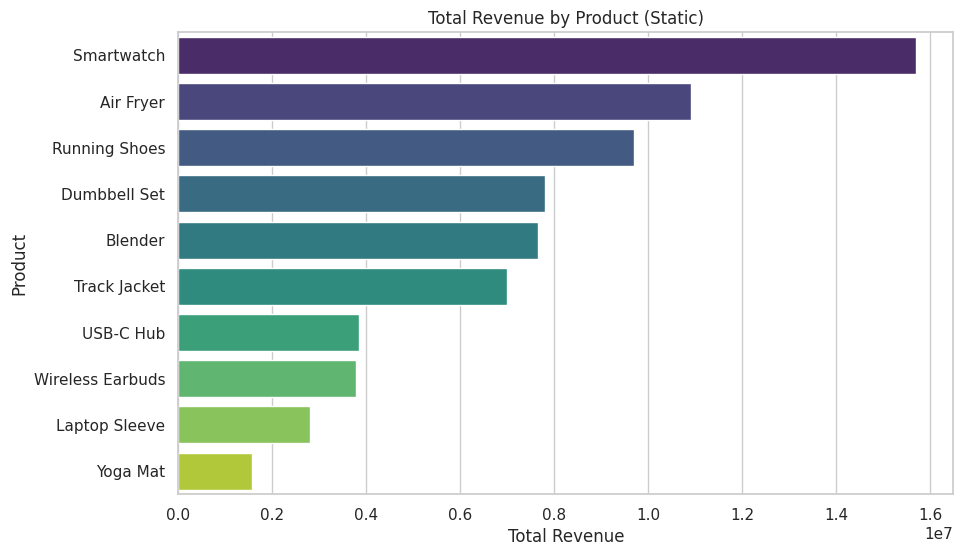

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1a. STATIC chart ---
revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_product, x="revenue", y="product", palette="viridis")
plt.title("Total Revenue by Product (Static)")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.show()

In [26]:
import plotly.express as px

# --- 1b. INTERACTIVE chart ---
# Keep category for the hover field
rev_cat_prod = sales_df.groupby(["product", "category"])["revenue"].sum().reset_index().sort_values("revenue", ascending=False)

fig = px.bar(rev_cat_prod, x="revenue", y="product", color="category",
             hover_data=["category", "revenue"],
             title="Total Revenue by Product (Interactive)",
             orientation='h')
fig.show()

**Your 1-2 sentence answer:**

_Type here._
For this specific manager request, the interactive `plotly` chart wins because it directly addresses the need for exact revenue figures on hover, reducing cognitive load and providing immediate precision without requiring managers to interpret axis scales. This enhances the ROI by making the data more accessible and actionable for the target audience.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [27]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt

# Create sliders
price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(), max=sales_df.unit_price.max(),
    step=100, description='Price Range:'
)

units_slider = widgets.IntRangeSlider(
    value=[sales_df.units_sold.min(), sales_df.units_sold.max()],
    min=sales_df.units_sold.min(), max=sales_df.units_sold.max(),
    step=1, description='Units Sold:'
)

def dynamic_filter(price_range, units_range):
    mask = (sales_df.unit_price >= price_range[0]) & (sales_df.unit_price <= price_range[1]) & \
           (sales_df.units_sold >= units_range[0]) & (sales_df.units_sold <= units_range[1])
    filtered = sales_df[mask]

    print(f"{len(filtered)} / {len(sales_df)} rows match")

    plt.figure(figsize=(8, 5))
    plt.scatter(sales_df.unit_price, sales_df.units_sold, c='lightgray', alpha=0.3, label='All Data')
    plt.scatter(filtered.unit_price, filtered.units_sold, c='blue', alpha=0.6, label='Filtered')
    plt.xlabel("Unit Price")
    plt.ylabel("Units Sold")
    plt.title("Dynamic Query: Price vs Units Sold")
    plt.legend()
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price Range:', max=4999.0, min=799.…

<function __main__.dynamic_filter(price_range, units_range)>

**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_
If the dataset grew 50x larger, two sliders might still be technically functional for filtering, but for visual exploration and understanding the relationships between `unit_price` and `units_sold`, a technique like **Overview + Detail** or **Zooming and Panning** would be more effective. This would allow users to see the full data context while also being able to magnify specific dense areas without visual clutter.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [28]:
store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Overview Bar Chart
    colors = ['blue' if s == selected_store else 'lightgray' for s in store_overview.store_id]
    sns.barplot(data=store_overview, x='store_id', y='revenue', palette=colors, ax=axes[0])
    axes[0].set_title("Store Revenue Overview")

    # 2. Category Breakdown
    store_data = sales_df[sales_df.store_id == selected_store]
    cat_data = store_data.groupby("category").revenue.sum()
    axes[1].pie(cat_data, labels=cat_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    axes[1].set_title(f"Category Breakdown: {selected_store}")

    # 3. Monthly Trend
    trend_data = store_data.groupby("month").revenue.sum().reset_index()
    sns.lineplot(data=trend_data, x='month', y='revenue', marker='o', ax=axes[2])
    axes[2].set_title(f"Monthly Trend: {selected_store}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

interact(store_coordinated_view, selected_store=widgets.Dropdown(options=stores["store_id"].values, description='Select Store:'))

interactive(children=(Dropdown(description='Select Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06')…

<function __main__.store_coordinated_view(selected_store)>

**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_
The "Overview bar chart" of total revenue per store serves as the **context**, showing the performance of all stores. The "Category breakdown" and "Monthly trend line" for the selected store act as the **focus**, providing detailed information about that specific store. This is closely related to brushing; brushing is the interaction mechanism (selecting a store from the overview) that defines the "focus" data subset within the broader "context" presented in the other views.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [29]:
# --- Part A: find the anomaly ---
anomaly_ranking = sales_df.groupby(["store_id", "product"]).units_sold.agg(
    ratio=lambda x: x.min() / x.median() if x.median() > 0 else 1
).reset_index().sort_values("ratio", ascending=True)

display(anomaly_ranking.head(5))

,store_id,product,ratio
25,S03,Smartwatch,0.185714
47,S05,USB-C Hub,0.250000
6,S01,Track Jacket,0.300000
27,S03,USB-C Hub,0.303030
19,S02,Yoga Mat,0.315789


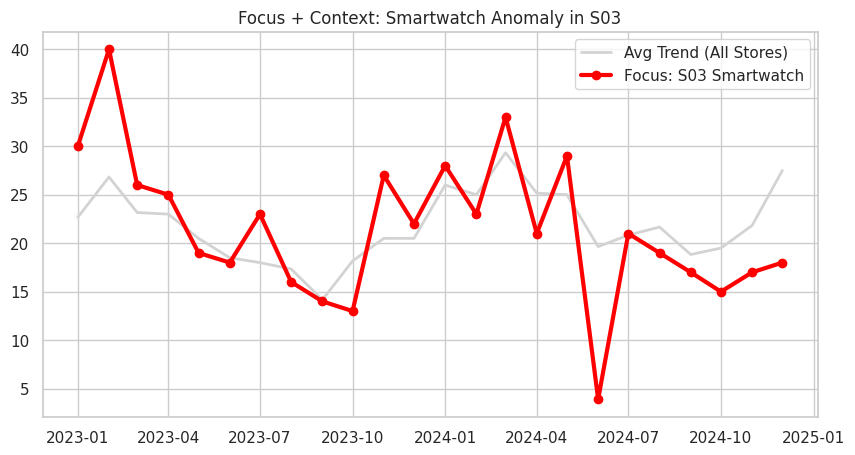

In [30]:
# --- Part B: drill-down ---
# 1. Plotly Overview
fig = px.line(sales_df, x="month", y="units_sold", color="product", line_group="store_id",
              hover_data=["store_id", "product"], title="Overview: Units Sold Trends per Store/Product")
fig.show()

# 2. Drill-down with Context
# The anomaly is S03 Smartwatch
target_store, target_prod = "S03", "Smartwatch"
focus = sales_df[(sales_df.store_id == target_store) & (sales_df["product"] == target_prod)]
context = sales_df[sales_df["product"] == target_prod].groupby("month").units_sold.mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(context.month, context.units_sold, color='lightgray', linewidth=2, label='Avg Trend (All Stores)')
plt.plot(focus.month, focus.units_sold, color='red', linewidth=3, marker='o', label=f'Focus: {target_store} {target_prod}')
plt.title(f"Focus + Context: {target_prod} Anomaly in {target_store}")
plt.legend()
plt.show()

**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_
To first *spot* the anomaly, I would use **eye fixation** (by observing the top N extreme drops in a sorted table like `anomaly_ranking`) or **hover** (on an overview trend chart). To *investigate* it, a **click-to-open panel** or a dedicated drill-down chart showing the specific anomalous trend alongside its context (e.g., average trend for that product across other stores) would be used. Using two different tiers is indeed the right call, as lower-cost tiers quickly identify potential issues, while higher-cost tiers provide the necessary detail for thorough investigation without overwhelming the initial overview.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [31]:
product_summary = sales_df.groupby("product").agg({
    "revenue": "sum",
    "profit": "sum",
    "avg_rating": "mean"
}).reset_index()

styled_table = product_summary.sort_values("revenue", ascending=False).style.bar(
    subset=["revenue"], color="#636EFA"
).bar(
    subset=["profit"], color="#EF553B"
).bar(
    subset=["avg_rating"], color="#00CC96"
).set_caption("Product Performance Summary (Sorted by Revenue)")

display(styled_table)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
1,Blender,7648773.000000,1860308.558382,4.039583
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


In [32]:
styled_table_profit = product_summary.sort_values("profit", ascending=False).style.bar(
    subset=["revenue"], color="#636EFA"
).bar(
    subset=["profit"], color="#EF553B"
).bar(
    subset=["avg_rating"], color="#00CC96"
).set_caption("Product Performance Summary (Sorted by Profit)")

display(styled_table_profit)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
1,Blender,7648773.000000,1860308.558382,4.039583
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


**Your observation (revenue-sorted vs profit-sorted top rows):**

_Type here._
My observation is that the top rows change significantly when sorting by profit compared to sorting by revenue. This indicates that products with high sales revenue are not always the most profitable. A manager would learn that focusing solely on revenue can be misleading, and understanding profitability is crucial for making informed business decisions about product promotion or discontinuation.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


/tmp/ipykernel_483/979779249.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




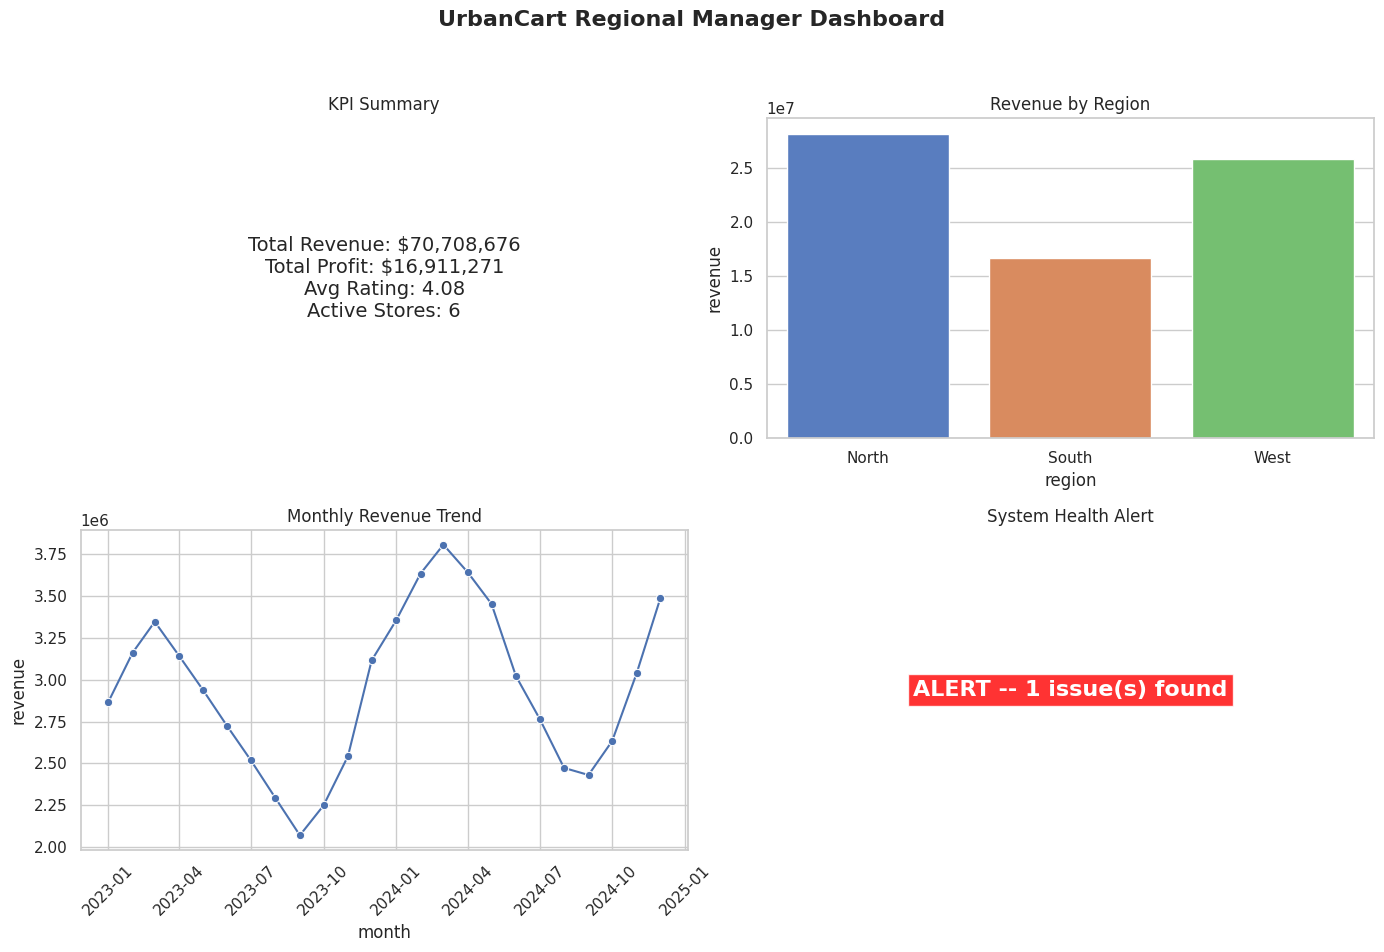

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. KPI Panel
total_rev = sales_df.revenue.sum()
total_prof = sales_df.profit.sum()
avg_rat = sales_df.avg_rating.mean()
num_stores = sales_df.store_id.nunique()

axes[0, 0].axis("off")
kpi_text = f"Total Revenue: ${total_rev:,.0f}\nTotal Profit: ${total_prof:,.0f}\nAvg Rating: {avg_rat:.2f}\nActive Stores: {num_stores}"
axes[0, 0].text(0.5, 0.5, kpi_text, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
axes[0, 0].set_title("KPI Summary")

# 2. Revenue by Region
reg_rev = sales_df.groupby("region").revenue.sum().reset_index()
sns.barplot(data=reg_rev, x='region', y='revenue', ax=axes[0, 1], palette='muted')
axes[0, 1].set_title("Revenue by Region")

# 3. Long-term Trend
monthly_rev = sales_df.groupby("month").revenue.sum().reset_index()
sns.lineplot(data=monthly_rev, x='month', y='revenue', ax=axes[1, 0], marker='o')
axes[1, 0].set_title("Monthly Revenue Trend")
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# 4. Peripheral Alert
anomalies = sales_df.groupby(["store_id", "product"]).units_sold.transform(lambda x: x < 0.25 * x.median())
num_issues = anomalies.sum()

axes[1, 1].axis("off")
color = 'red' if num_issues > 0 else 'green'
status = f"ALERT -- {int(num_issues)} issue(s) found" if num_issues > 0 else "SYSTEM OK"
axes[1, 1].text(0.5, 0.5, status, fontsize=16, color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor=color, alpha=0.8))
axes[1, 1].set_title("System Health Alert")

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._
1. The **Coordinated Views & Cross-View Brushing** (Task 3) likely provides the biggest time saving. It directly addresses Complaint #2 ("comparing stores... flipping between many separate PDF pages") by allowing managers to select a store and instantly see its performance across multiple related metrics (category breakdown, monthly trend) without losing the context of other stores. This drastically reduces the effort and time spent switching between different reports or views.

2. **Focus + Context Drill-Down** (Task 4) was arguably the hardest to implement well due to the need to elegantly combine the anomalous focus data with a relevant context line. The main design trade-off was between providing enough detail in the focus view without overwhelming it, while ensuring the context line was present but not distracting. The challenge was balancing **information density** with **clarity**, especially in choosing what constituted the "average trend" for context and how to visually differentiate it effectively from the anomalous "focus" line.

3. If I had to add one more interaction technique, **Network Zooming** (similar to a hierarchical drill-down for product categories or store regions) could be highly useful. For instance, a manager might want to see overall performance for "Electronics" (zoomed out), then click into "Smartwatch" (zoomed in) to see its specific regional performance, and then zoom back out. This would be valuable for Complaint #1 ("can't drill into *why* a number moved") by allowing a structured exploration of data from high-level aggregates down to granular details within hierarchical categories like product categories or geographical regions.